
# QUESTION 1

{accuracy: 10}
{reasoning: 2}

Train and tune a Random Forest Classifier and an SVM Classifier with an RBF kernel using a classification dataset of your choice. Perform hyperparameter tuning for both models and compare their performance (accuracy, confusion matrix, classification report) and computational efficiency (training time).

## Importing necessary libraries

In [4]:
import numpy as np
import pandas as pd
import time
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load the dataset

Use the load_wine dataset from sklearn.datasets.
Specify X and y (features and the target variable)

In [10]:
data = load_wine()
# add code here
X = data.data
y = data.target

## Perform Train-Test Split

Use "train_test_split" function for dataset  division

In [14]:
# add code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Initialize the Random Forest Classifier model and the SVM model

In [17]:
# add code here
rf_model = RandomForestClassifier(random_state=42)
svm_model = SVC(kernel='rbf', random_state=42)

## Set up the parameters for tuning

Use n_estimators, max_depth, and min_samples_split for the parameters of random forest classifier.

Use C and gamma for the parameters of SVM model.

In [21]:
# add code here
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

## Perform hyperparameter tuning for Random Forest using GridSearchCV


In [24]:
# add code here
start_time = time.time()
rf_grid_search = GridSearchCV(rf_model, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid_search.fit(X_train, y_train)
rf_training_time = time.time() - start_time
# printing out the best paramaters and timings
# add code here
print("Random Forest Best Parameters:", rf_grid_search.best_params_)
print(f"Random Forest Training Time: {rf_training_time:.4f} seconds")

/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/homebrew/anaconda3/

Random Forest Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Training Time: 3.4173 seconds


## Perform hyperparameter tuning for SVM with RBF kernel using GridSearchCV

In [26]:
# add code here
start_time = time.time()
svm_grid_search = GridSearchCV(svm_model, svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid_search.fit(X_train, y_train)
svm_training_time = time.time() - start_time
# printing out the best paramaters and timings
# add code here
print("SVM Best Parameters:", svm_grid_search.best_params_)
print(f"SVM Training Time: {svm_training_time:.4f} seconds")

SVM Best Parameters: {'C': 100, 'gamma': 'scale'}
SVM Training Time: 0.0738 seconds


## Display the predictions and evaluations

In [28]:
# Predictions and evaluation
# add code here
best_rf = rf_grid_search.best_estimator_
best_svm = svm_grid_search.best_estimator_

rf_predictions = best_rf.predict(X_test)
svm_predictions = best_svm.predict(X_test)

# Print the accuracy, confusion matrix, and the classification report for random forest
# add code here
print("Random Forest Classifier")
print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))
print("Classification Report:")
print(classification_report(y_test, rf_predictions, target_names=data.target_names))

# Print the accuracy, confusion matrix, and the classification report for RBF kernal
# add code here
print("SVM Classifier with RBF Kernel")
print(f"Accuracy: {accuracy_score(y_test, svm_predictions):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_predictions))
print("Classification Report:")
print(classification_report(y_test, svm_predictions, target_names=data.target_names))

Random Forest Classifier
Accuracy: 1.0000
Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]
Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

SVM Classifier with RBF Kernel
Accuracy: 0.8333
Confusion Matrix:
[[14  0  0]
 [ 0 10  4]
 [ 1  1  6]]
Classification Report:
              precision    recall  f1-score   support

     class_0       0.93      1.00      0.97        14
     class_1       0.91      0.71      0.80        14
     class_2       0.60      0.75      0.67         8

    accuracy                           0.83        36
   macro avg       0.81      0.82      0.81        36
weighted avg       0.85      0.83      0.83    

## Display which model is faster

In [30]:
# add code here
print(f"Random Forest Training Time: {rf_training_time:.4f} seconds")
print(f"SVM Training Time: {svm_training_time:.4f} seconds")

if rf_training_time < svm_training_time:
    print("Random Forest is faster!")
else:
    print("SVM is faster!")

Random Forest Training Time: 3.4173 seconds
SVM Training Time: 0.0738 seconds
SVM is faster!


# QUESTION 2

Implement and visualize the decision boundaries for three different SVM kernels (Linear, Polynomial, and RBF) using a synthetic 2D dataset. After that, apply a handcrafted feature expansion to transform the dataset into a higher-dimensional space and train a linear SVM on this transformed data. Visualize the decision boundary in the original 2D space, and discuss the impact of the different kernels and feature expansion on the separability of the data.

## Importing necessary libraries

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import make_circles, make_moons

## Generate synthetic 2D dataset with non-linear patterns

Use the inbuilt make_moons dataset to generate the synthetic 2D dataset

In [36]:
# add code here
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

## Create a function to plot decision boundaries for a classifier

{accuracy: 5}

In [39]:
def plot_decision_boundaries(X, y, clf, title, feature_transform=None):
    # initialize the step size in the mesh for plotting
    h = 0.02

    # Define the grid range based on the dataset
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # This if-else block is executed when feature transformation is performed (in the last part of the question)
    if feature_transform:
        grid_points = feature_transform(np.c_[xx.ravel(), yy.ravel()])
    else:
        grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Predict class labels for each point in the grid
    Z = clf.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary as a contour plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.contour(xx, yy, Z, colors='k', linewidths=0.5)

    # Plot the scatter plot of the actual data points on top
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k', s=40)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.tight_layout()
    plt.show()

## Train an SVM classifier with a linear kernel and plot the decision boundary for the same

{accuracy: 2}

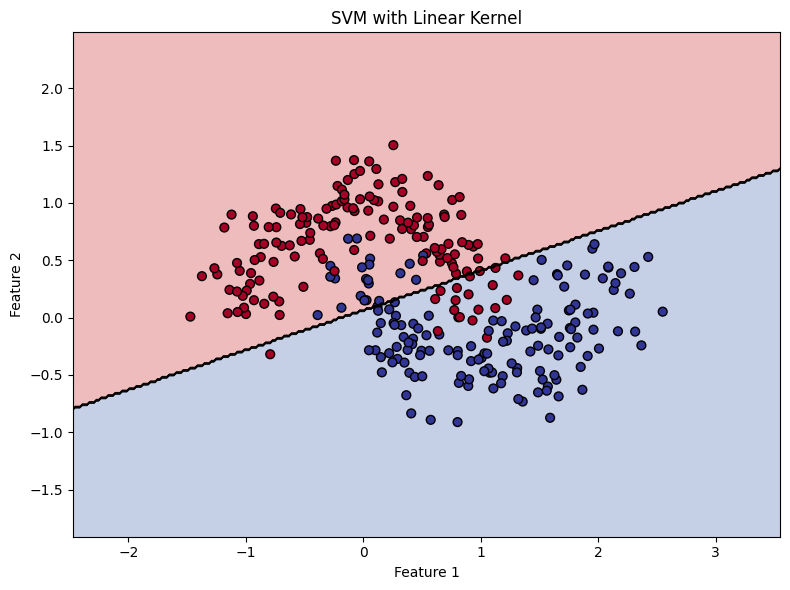

In [48]:
svm_linear = svm.SVC(kernel='linear', C=1.0)
svm_linear.fit(X, y)
plot_decision_boundaries(X, y, svm_linear, 'SVM with Linear Kernel')

## Train an SVM classifier with a polynomial kernel of degree 3 and plot the decision boundary for the same

{accuracy: 2}

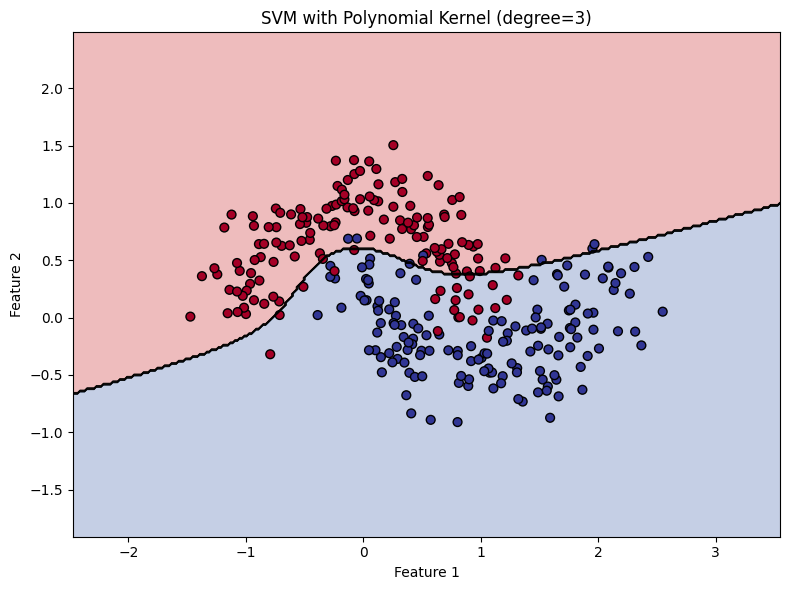

In [50]:
# add code here
svm_poly = svm.SVC(kernel='poly', degree=3, C=1.0)
svm_poly.fit(X, y)
plot_decision_boundaries(X, y, svm_poly, 'SVM with Polynomial Kernel (degree=3)')

## Train an SVM classifier with an RBF (Gaussian) kernel and plot the decision boundary for the same

{accuracy 2}

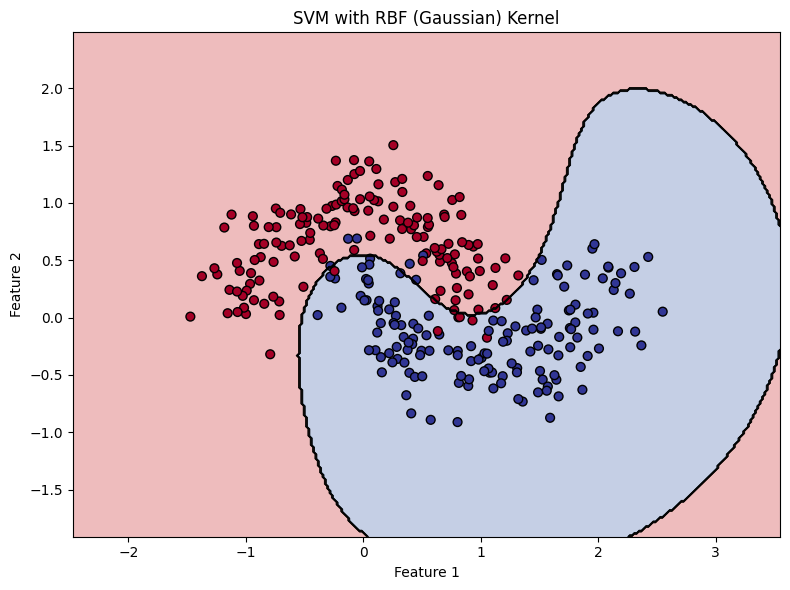

In [52]:
# add code here
svm_rbf = svm.SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X, y)
plot_decision_boundaries(X, y, svm_rbf, 'SVM with RBF (Gaussian) Kernel')

## Handcrafted Feature Expansion

{accuracy: 3}

### Use Polynomial Features to manually expand the feature space (degree 3)

In [55]:
# add code here
poly = PolynomialFeatures(degree=3, include_bias=False)
X_expanded = poly.fit_transform(X)
print(f"Original feature shape: {X.shape}")
print(f"Expanded feature shape: {X_expanded.shape}")

Original feature shape: (300, 2)
Expanded feature shape: (300, 9)


### Now, train an SVM classifier with a linear kernel on the expanded feature set

In [57]:
# add code here
svm_linear_expanded = svm.SVC(kernel='linear', C=1.0)
svm_linear_expanded.fit(X_expanded, y)
print("Linear SVM trained on expanded feature space.")

Linear SVM trained on expanded feature space.


### Plot the decision boundary in the original 2D space

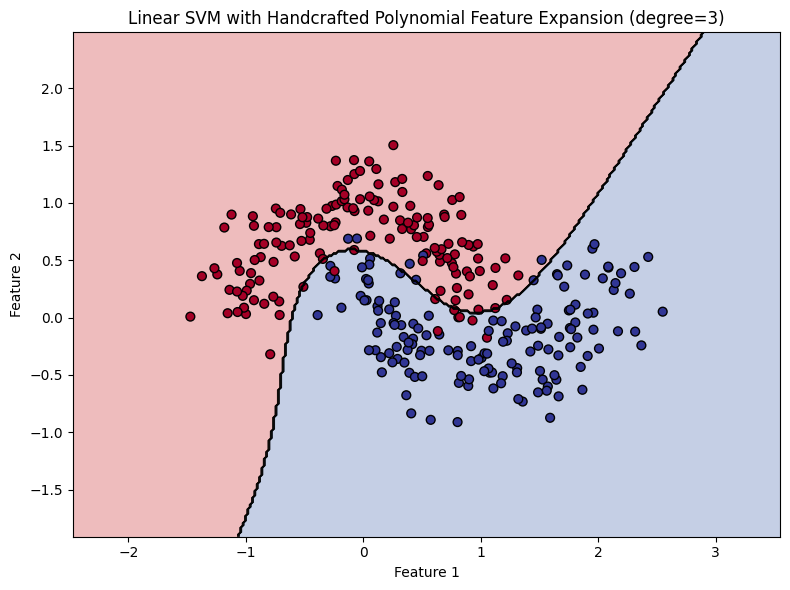

In [59]:
# add code here
plot_decision_boundaries(
    X, y, svm_linear_expanded,
    'Linear SVM with Handcrafted Polynomial Feature Expansion (degree=3)',
    feature_transform=poly.transform
)

# QUESTION 3

{reasoning: 5}



Consider a dataset $\{(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)\}$ where $x_i \in \mathbb{R}^2$ and $y_i \in \{+1, -1\}$. Suppose we want to apply the kernel trick to a Support Vector Machine (SVM) to classify the data, and we choose to use the polynomial kernel of degree 2:

$$
K(x, x') = (x \cdot x' + 1)^2
$$

1. **Feature Mapping:**
   - Compute the feature mapping $\phi(x)$ corresponding to the polynomial kernel $K(x, x')$. Specifically, find the transformation $\phi: \mathbb{R}^2 \rightarrow \mathbb{R}^6$ that corresponds to this kernel function.

2. **Kernel Matrix:**
   - Given the following points $x_1 = (1, 2)$ and $x_2 = (3, 4)$, construct the kernel matrix $K$ for these two points. Show the steps involved in calculating each entry of the matrix using the given polynomial kernel.

3. **Decision Function:**
   - Suppose the SVM decision function is expressed in the feature space as $f(x) = w \cdot \phi(x) + b$, where $w$ and $b$ are learned parameters. Explain how the decision function in the original space can be derived using the kernel function.


## Solution

Add your solution here

In [ ]:
1. Feature Mapping φ(x)
K(x,x′)=(x⋅x′+1)2
Let x=(x1,x2)x = (x_1, x_2)
x=(x1,x2) and x′=(x1′,x2′)
x′=(x1′,x2′). Expanding:
K(x,x′)=(x1 x1′ +x2 x2′+1)2
=x12 x1′2+x22 x2′ 2+1+2x1 x2,x1′ x2′+2x1 x1′+2x2 x2′




In [ ]:
2. Given x1=(1,2)x_1 = (1, 2)
x1=(1,2) and x2=(3,4)x_2 = (3, 4)
x2=(3,4), the kernel matrix is:

K=[K(x1,x1)K(x2,x1) K(x1,x2)K(x2,x2)]

K(x1,x1)=(1⋅1+2⋅2+1)2=(1+4+1)2=62=36
K(x2,x2)=(3⋅3+4⋅4+1)2=(9+16+1)2=262=676
K(x1,x2)=(1⋅3+2⋅4+1)2=(3+8+1)2=122=144
K(x2,x1)=K(x1,x2)=144 (kernel matrices are symmetric)

In [ ]:
3. In the feature space, the SVM decision function is:
f(x)=w⋅ϕ(x)+b
w=i=1∑n αi yi ϕ(xi)
Substituting into the decision function:
f(x)=(i=1∑n αi yi ϕ(xi))⋅ϕ(x)+b=i=1∑n αi yi (ϕ(xi)⋅ϕ(x))+b

f(x) = i=1∑n αiyiK(xi,x) + b
We never need to explicitly compute ϕ(x) or w. The decision function only requires computing the kernel K(xi,x)
between each support vector and the new point x